In [53]:
import pandas as pd

df = pd.read_json("../../data/cleaned/clean_dataframe.json")

def check_and_fix_price(df):
    df = df.copy()

    # Convert price column to float to ensure safe numerical operations
    df["price"] = pd.to_numeric(df["price"], errors="coerce").astype(float)

    # Detect suspiciously high prices (possible scale error)
    df["price_flag"] = df["price"] > 5_000_000

    # Fix price scale issue by dividing by 100 for flagged rows
    df.loc[df["price_flag"], "price"] = df.loc[df["price_flag"], "price"] / 100

    # Convert final cleaned price back to integer (nullable Int64 type)
    df["price"] = df["price"].round(0).astype("Int64")

    return df


# Run cleaning function
df = check_and_fix_price(df)

# Save cleaned dataset to a new JSON file
df.to_json(
    "../../data/cleaned/clean_dataframe_fixed.json",
    orient="records",
    indent=2,
    force_ascii=False
)

print("Done: price cleaned + file saved!")

Done: price cleaned + file saved!


In [54]:
price_raw = '1000000.00'
price = pd.to_numeric(price_raw, errors="coerce")
price = None if pd.isna(price) else int(price)
print(price)

1000000


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_price_per_m2_by_province(df):
    df = df.copy()

    # Ensure numeric
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    # Remove invalid rows
    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]

    # Create price per m²   
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # Normalize province (important for grouping)
    df["province"] = df["province"].str.lower()

    # MAIN CHART — WEIGHTED BAR (SUM/SUM €/m²)
    # Group
    province_price = (
        df.groupby("province")["price_per_m2"]
        .mean()
        .sort_values(ascending=False)
    )

    print(province_price)  

    # Plot
    plt.figure(figsize=(12, 6))
    province_price.plot(kind="bar")

    plt.title("Average Price per m² by Province")
    plt.ylabel("€/m²")
    plt.xlabel("Province")

    plt.xticks(rotation=45)

    plt.tight_layout()
    # plt.savefig("../../images/province_weighted_price_per_m2.png", dpi=300)
    plt.savefig("province_weighted_price_per_m2.png", dpi=300)
    plt.show()

    # SUPPORT CHART — BOXPLOT (distribution)
    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df,
        x="province",
        y="price_per_m2"
    )

    plt.title("Price per m² Distribution by Province")
    plt.xlabel("Province")
    plt.ylabel("€/m²")

    plt.xticks(rotation=45)
    plt.tight_layout()

    # plt.savefig("../../images/province_price_distribution_boxplot.png", dpi=300)
    plt.savefig("province_price_distribution_boxplot.png", dpi=300)
    plt.show()


province
brabant-wallon    5222.750471
brussels          3977.252147
namur             3928.791698
luxembourg        3661.689371
west-flanders     3453.039440
vlaams-brabant    3244.996650
liege             3218.699163
antwerp           2946.882934
east-flanders     2657.656326
hainaut           2623.210772
limburg           2353.931139
Name: price_per_m2, dtype: float64


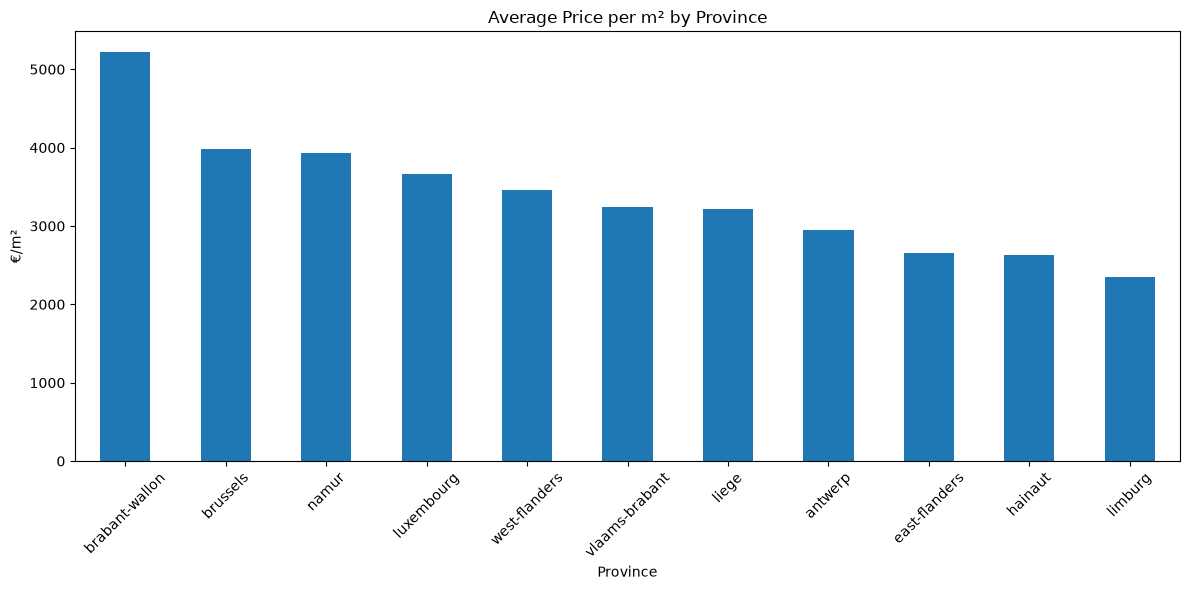

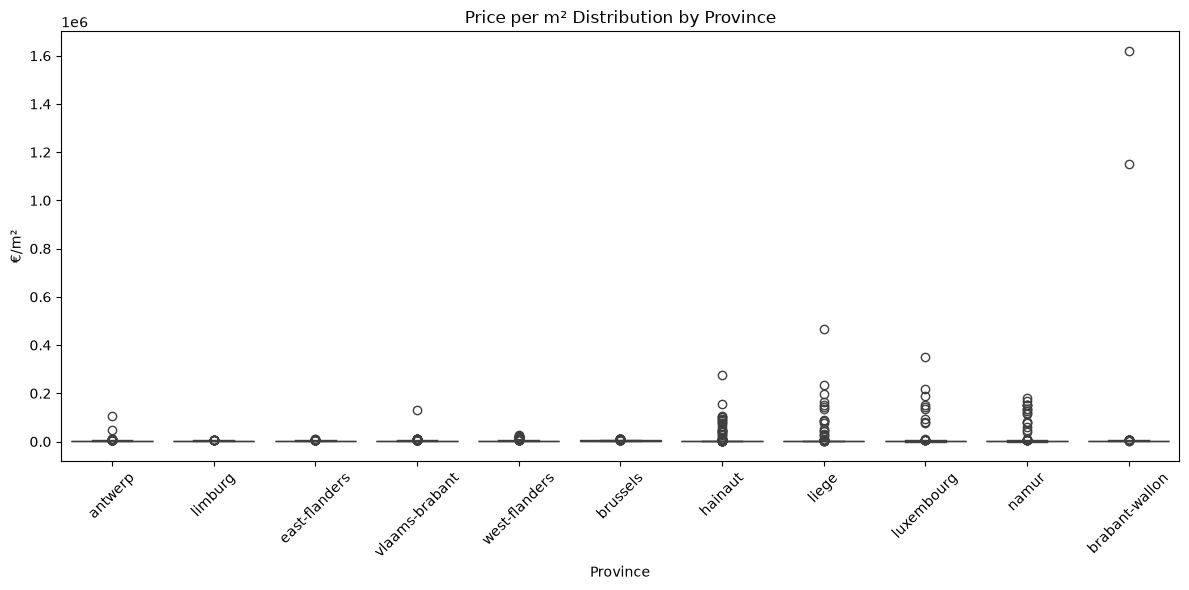

In [56]:

# Load cleaned dataset
data = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")
plot_price_per_m2_by_province(data)

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_price_dashboard(df):
    df = df.copy()

    # =========================
    # CLEAN DATA
    # =========================
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]

    df["province"] = df["province"].str.lower()

    # Feature engineering
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # =========================
    # METRICS
    # =========================

    # Weighted price per m² (MOST IMPORTANT - market truth)
    # province_weighted = df.groupby("province").apply(
    #     lambda x: x["price"].sum() / x["livable_surface"].sum()
    # ).sort_values(ascending=False)
    province_weighted = (
        df.groupby("province")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    # Number of listings (data reliability)
    province_count = df["province"].value_counts()

    # Variability (robust version using IQR instead of STD)
    q75 = df.groupby("province")["price_per_m2"].quantile(0.75)
    q25 = df.groupby("province")["price_per_m2"].quantile(0.25)

    province_variability = (q75 - q25).sort_values(ascending=False)

    # =========================
    # PLOT DASHBOARD (1 FIGURE)
    # =========================

    # fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()  # index 0-3
    
    # -------------------------
    # Chart 1: Market price per m² (area-weighted average)
    # -------------------------
    province_weighted.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Area-weighted Price per m² by Province")
    axes[0].set_ylabel("€/m²")
    axes[0].tick_params(axis="x", rotation=45)

    # -------------------------
    # Chart 2: Number of listings (data reliability)
    # -------------------------
    province_count.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Number of Properties per Province")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45)

    # -------------------------
    # Chart 3: Price variability (IQR - market stability)
    # -------------------------
    province_variability.plot(kind="bar", ax=axes[2])
    axes[2].set_title("Price per m² Variability (IQR)")
    axes[2].set_ylabel("IQR €/m²")
    axes[2].tick_params(axis="x", rotation=45)

    # -------------------
    # 4. BOX PLOT 
    # -------------------
    order = df.groupby("province")["price_per_m2"].median().sort_values().index

    sns.boxplot(
        data=df,
        x="province",
        y="price_per_m2",
        order=order,
        ax=axes[3]
    )

    axes[3].set_title("Distribution (Boxplot)")
    axes[3].tick_params(axis="x", rotation=45)

    # Layout fix
    plt.tight_layout()

    # Save image
    plt.savefig("province_dashboard.png", dpi=300)

    # Show
    plt.show()

In [58]:
def generate_insights(df):
    df = df.copy()

    # Ensure clean
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")
    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]
    df["province"] = df["province"].str.lower()

    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # =========================
    # METRICS
    # =========================

    weighted = df.groupby("province").apply(
        lambda x: x["price"].sum() / x["livable_surface"].sum()
    )

    count = df["province"].value_counts()

    variability = df.groupby("province")["price_per_m2"].quantile(0.75) - \
                  df.groupby("province")["price_per_m2"].quantile(0.25)

    # =========================
    # TOP / BOTTOM ANALYSIS
    # =========================

    most_expensive = weighted.idxmax()
    cheapest = weighted.idxmin()

    most_reliable = count.idxmax()
    least_data = count.idxmin()

    most_volatile = variability.idxmax()
    most_stable = variability.idxmin()

    # =========================
    # TEXT REPORT
    # =========================

    report = f"""
    📊 REAL ESTATE INSIGHTS REPORT (BELGIUM)

    💰 Price Level:
    - Most expensive province: {most_expensive}
    - Cheapest province: {cheapest}

    📦 Data Coverage:
    - Most listings: {most_reliable}
    - Least represented: {least_data}

    📉 Market Stability:
    - Most volatile (uneven prices): {most_volatile}
    - Most stable market: {most_stable}

    🧠 Key Insight:
    - High-priced provinces tend to show higher variability, indicating a mix of luxury and standard properties.
    - Data coverage is uneven across provinces, which may bias comparisons in low-sample regions.
    """

    print(report)

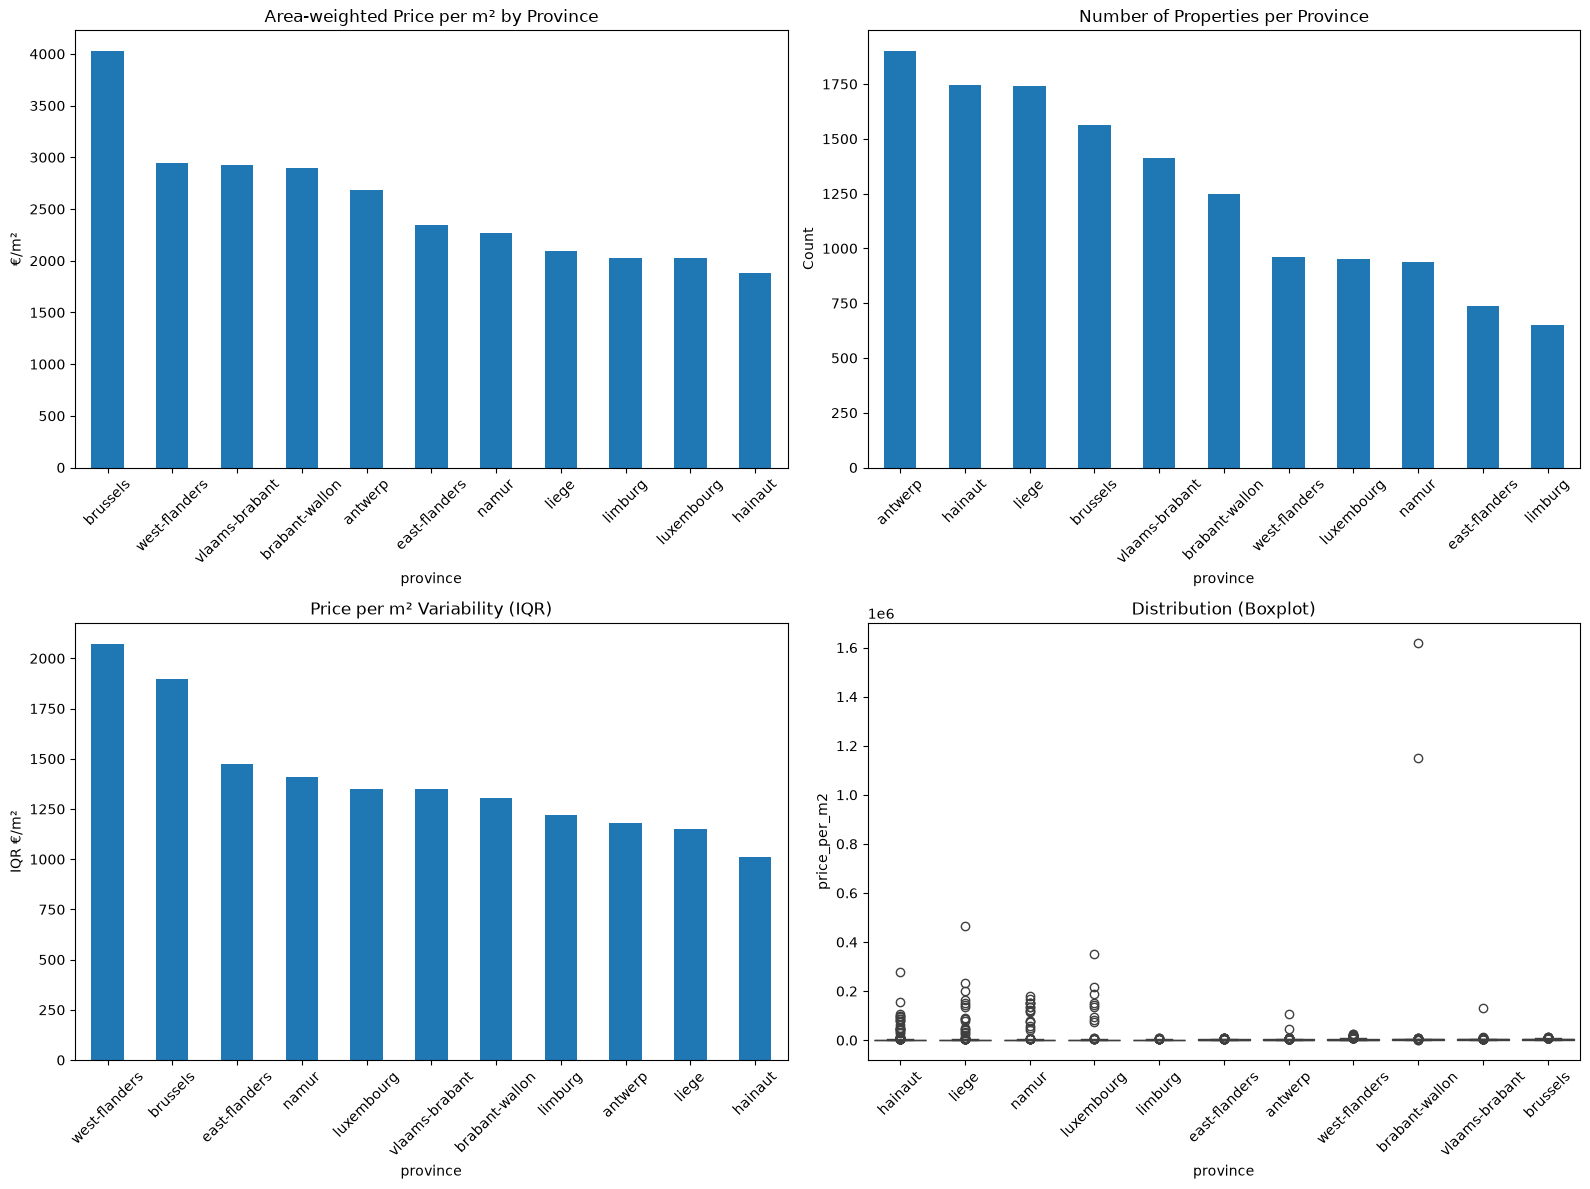


    📊 REAL ESTATE INSIGHTS REPORT (BELGIUM)

    💰 Price Level:
    - Most expensive province: brussels
    - Cheapest province: hainaut

    📦 Data Coverage:
    - Most listings: antwerp
    - Least represented: limburg

    📉 Market Stability:
    - Most volatile (uneven prices): west-flanders
    - Most stable market: hainaut

    🧠 Key Insight:
    - High-priced provinces tend to show higher variability, indicating a mix of luxury and standard properties.
    - Data coverage is uneven across provinces, which may bias comparisons in low-sample regions.
    


In [59]:
data = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")
plot_price_dashboard(data)

generate_insights(data)

In [60]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
import pandas as pd


def generate_pdf_report(df, output_path="real_estate_report.pdf"):
    df = df.copy()

    # =========================
    # CLEAN DATA
    # =========================
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")
    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]
    df["province"] = df["province"].str.lower()
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # =========================
    # METRICS
    # =========================
    weighted = df.groupby("province").apply(
        lambda x: x["price"].sum() / x["livable_surface"].sum()
    )

    count = df["province"].value_counts()

    iqr = df.groupby("province")["price_per_m2"].quantile(0.75) - \
          df.groupby("province")["price_per_m2"].quantile(0.25)

    # Top insights
    most_expensive = weighted.idxmax()
    cheapest = weighted.idxmin()
    most_data = count.idxmax()
    least_data = count.idxmin()

    # =========================
    # CREATE PDF
    # =========================
    doc = SimpleDocTemplate(output_path)
    styles = getSampleStyleSheet()
    elements = []

    # Title
    title = Paragraph("Belgium Real Estate Market Report", styles["Title"])
    elements.append(title)
    elements.append(Spacer(1, 12))

    # Executive summary
    summary_text = f"""
    <b>Executive Summary</b><br/><br/>
    This report analyzes real estate prices across Belgian provinces using 
    weighted price per square meter, listing volume, and price variability.<br/><br/>

    <b>Key Findings:</b><br/>
    - Most expensive province: {most_expensive}<br/>
    - Cheapest province: {cheapest}<br/>
    - Highest data volume: {most_data}<br/>
    - Lowest data volume: {least_data}<br/>
    """

    elements.append(Paragraph(summary_text, styles["Normal"]))
    elements.append(Spacer(1, 12))

    # Table data
    table_data = [["Province", "Weighted €/m²", "Listings", "IQR"]]

    for p in weighted.index:
        table_data.append([
            p,
            round(weighted[p], 2),
            int(count[p]),
            round(iqr[p], 2)
        ])

    table = Table(table_data)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.grey),
        ("TEXTCOLOR", (0,0), (-1,0), colors.whitesmoke),
        ("GRID", (0,0), (-1,-1), 0.5, colors.black),
        ("PADDING", (0,0), (-1,-1), 6),
    ]))

    elements.append(table)

    # Build PDF
    doc.build(elements)

    print(f"PDF report saved to: {output_path}")

In [61]:
data = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")

generate_pdf_report(data, "belgium_real_estate_report.pdf")

PDF report saved to: belgium_real_estate_report.pdf


In [62]:
def clean_data(df):
    df = df.copy()

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]

    df["province"] = df["province"].str.lower()
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    return df

In [63]:
def compute_metrics(df):
    weighted = df.groupby("province").apply(
        lambda x: x["price"].sum() / x["livable_surface"].sum()
    ).sort_values(ascending=False)

    count = df["province"].value_counts()

    iqr = df.groupby("province")["price_per_m2"].quantile(0.75) - \
          df.groupby("province")["price_per_m2"].quantile(0.25)

    return weighted, count, iqr

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dashboard(df, weighted, count, iqr):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    weighted.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Weighted €/m²")

    count.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Number of Properties")

    iqr.plot(kind="bar", ax=axes[2])
    axes[2].set_title("Market Variability (IQR)")

    sns.boxplot(data=df, x="province", y="price_per_m2", ax=axes[3])

    axes[3].set_title("Distribution (Boxplot)")
    axes[3].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [65]:
def generate_insights(weighted, count, iqr):
    return f"""
    📊 REAL ESTATE INSIGHTS

    💰 Most expensive: {weighted.idxmax()}
    💸 Cheapest: {weighted.idxmin()}

    📦 Most data: {count.idxmax()}
    📉 Least data: {count.idxmin()}

    📊 Most volatile: {iqr.idxmax()}
    📊 Most stable: {iqr.idxmin()}
    """

In [67]:
def format_insight_block(weighted, count, iqr):
    most_expensive = weighted.idxmax()
    cheapest = weighted.idxmin()

    most_data = count.idxmax()
    least_data = count.idxmin()

    most_volatile = iqr.idxmax()
    most_stable = iqr.idxmin()

    text = f"""
    <b>📊 REAL ESTATE INSIGHTS REPORT (BELGIUM)</b><br/><br/>

    <b>💰 Price Level:</b><br/>
    - Most expensive province: {most_expensive}<br/>
    - Cheapest province: {cheapest}<br/><br/>

    <b>📦 Data Coverage:</b><br/>
    - Most listings: {most_data}<br/>
    - Least represented: {least_data}<br/><br/>

    <b>📉 Market Stability:</b><br/>
    - Most volatile (uneven prices): {most_volatile}<br/>
    - Most stable market: {most_stable}<br/><br/>

    <b>🧠 Key Insight:</b><br/>
    - High-priced provinces tend to show higher variability, indicating a mix of luxury and standard properties.<br/>
    - Data coverage is uneven across provinces, which may bias comparisons in low-sample regions.
    """

    return text

In [71]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.platypus import PageBreak


def generate_pdf_report(df, weighted, count, iqr, insight_text, output="report.pdf"):
    """
    Generate a full business-style real estate PDF report including:
    - Title
    - Executive insights
    - Key metrics table
    - Dashboard chart image
    """

    # =========================
    # INIT PDF
    # =========================
    doc = SimpleDocTemplate(output)
    styles = getSampleStyleSheet()
    elements = []

    # =========================
    # TITLE
    # =========================
    title = Paragraph(
        "Belgium Real Estate Market Report",
        styles["Title"]
    )
    elements.append(title)
    elements.append(Spacer(1, 12))

    # =========================
    # EXECUTIVE INSIGHTS
    # =========================
    elements.append(Paragraph("<b>Executive Insights</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    elements.append(Paragraph(insight_text, styles["Normal"]))
    elements.append(Spacer(1, 12))

    # =========================
    # METRICS TABLE
    # =========================
    elements.append(Paragraph("<b>Market Overview Table</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    table_data = [["Province", "Weighted €/m²", "Listings", "IQR"]]

    for province in weighted.index:
        table_data.append([
            province,
            round(weighted[province], 2),
            int(count[province]),
            round(iqr[province], 2)
        ])

    table = Table(table_data)

    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("PADDING", (0, 0), (-1, -1), 6),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ]))

    elements.append(table)
    elements.append(Spacer(1, 12))

    # =========================
    # DASHBOARD IMAGE
    # =========================
    elements.append(PageBreak())
    elements.append(Paragraph("<b>Visual Dashboard</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    try:
        elements.append(Image("province_dashboard.png", width=500, height=350))
    except:
        elements.append(Paragraph("Dashboard image not found.", styles["Normal"]))

    # =========================
    # BUILD PDF
    # =========================
    doc.build(elements)

    print(f"PDF saved successfully → {output}")

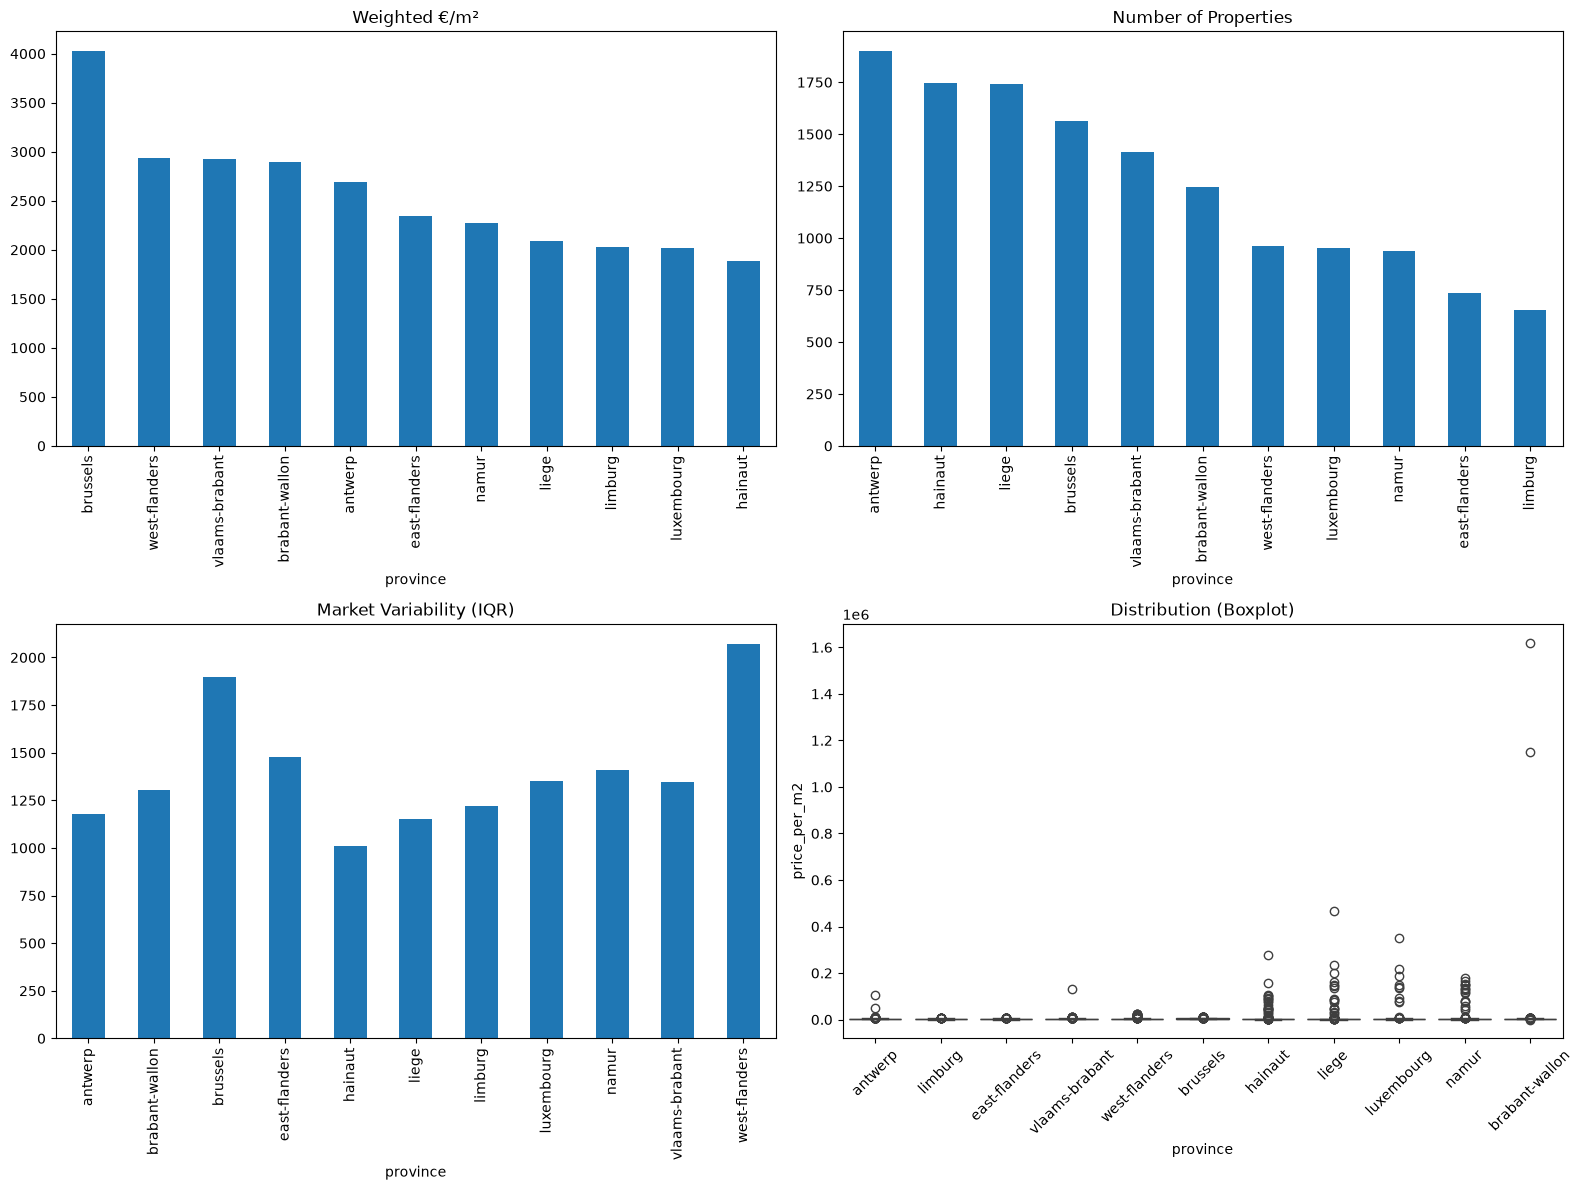

PDF saved successfully → report.pdf


In [72]:
df = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")

df_clean = clean_data(df)
weighted, count, iqr = compute_metrics(df_clean)

insight_text = generate_insights(weighted, count, iqr)

plot_dashboard(df_clean, weighted, count, iqr)

generate_pdf_report(df_clean, weighted, count, iqr, insight_text)